# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# Part 1 — Data and leakage Check


Before training any model, we need to understand what we are working with. Let's start from scratch and see what the data actually looks like.



## Step 1 – What's in the data folder?



In [2]:
DATA_DIR = "data"

classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print("Subdirectories found:", classes)

records = []
for cls in classes:
    paths = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*.tif")))
    for p in paths:
        records.append({"class": cls, "path": p})

df = pd.DataFrame(records)
print(f"\nTotal images: {len(df)}")
print(df["class"].value_counts().sort_index().to_string())


Subdirectories found: ['class1', 'class2', 'class3', 'class4']

Total images: 400
class
class1    100
class2    100
class3    100
class4    100


## Step 2 – A first look at the images



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2570..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6425..65535].


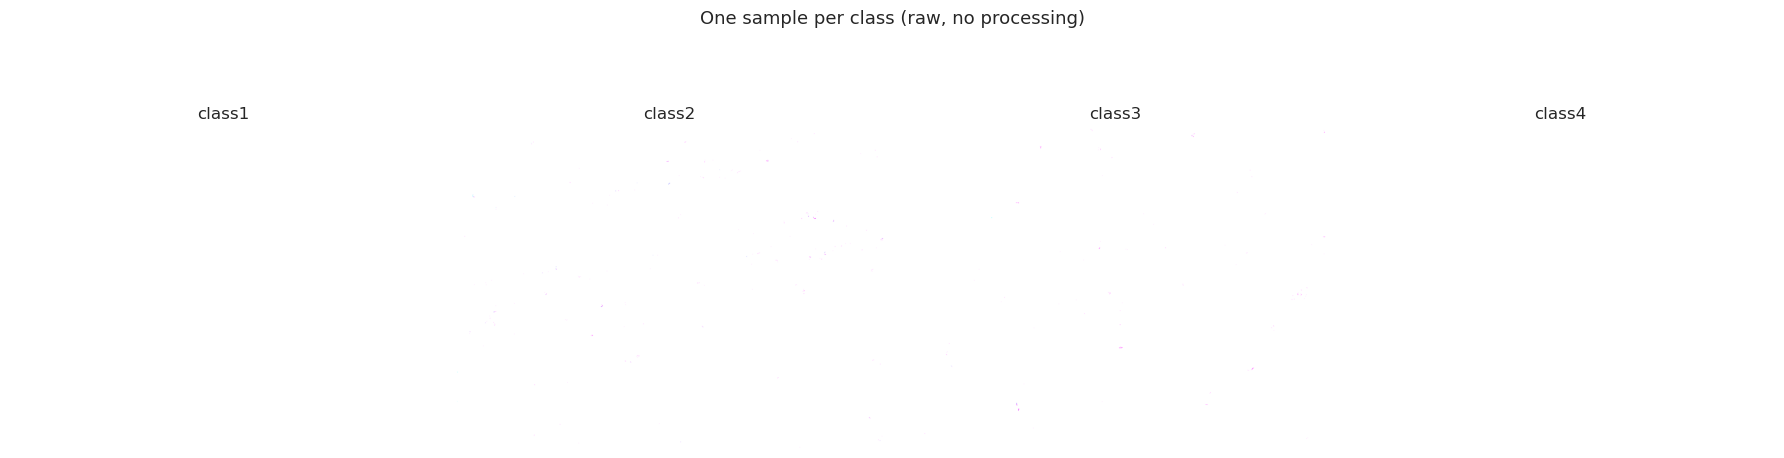

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, cls in zip(axes, classes):
    sample_path = df[df["class"] == cls]["path"].iloc[0]
    img = tifffile.imread(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.suptitle("One sample per class (raw, no processing)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Step 3 – Something looks off

The images are displaying but they are white.

Let's print  `dtype`, `shape`, `min`, and `max`.


In [4]:
for cls in classes:
    sample_path = df[df["class"] == cls]["path"].iloc[0]
    img = tifffile.imread(sample_path)
    print(f"{cls}  |  shape: {img.shape}  |  dtype: {img.dtype}  |  min: {img.min():6}  |  max: {img.max():6}")


class1  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:   2570  |  max:  65535
class2  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:      0  |  max:  65535
class3  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:      0  |  max:  65535
class4  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:   6425  |  max:  65535


## Step 4 –  the bit-depth issue

Some images the max value is around `65535` instead of `255`?
That's a **16-bit unsigned integer** (`uint16`), not 8-bit (`uint8`).


| Type | Range | Bits |
|---|---|---|
| `uint8` | 0 – 255 | 8 |
| `uint16` | 0 – 65 535 | 16 |

If we pass both to a neural network without normalization, the 16-bit images will dominate
the 8-bit ones by a factor of up to 256x. Let's see how widespread this issue is.


In [5]:
dtype_counts = Counter()

for path in df["path"]:
    img = tifffile.imread(path)
    dtype_counts[str(img.dtype)] += 1

print("Bit-depth breakdown across the full dataset:")
for dtype, count in sorted(dtype_counts.items()):
    pct = count / len(df) * 100
    print(f"  {dtype:8s}  {count:4d} images  ({pct:.1f}%)")


Bit-depth breakdown across the full dataset:
  uint16     381 images  (95.2%)
  uint8       19 images  (4.8%)


### Is the mixing per-class or random?

Let's break it down per class to understand the pattern.


In [6]:
records_with_dtype = []
for _, row in df.iterrows():
    img = tifffile.imread(row["path"])
    records_with_dtype.append({
        "class": row["class"],
        "path":  row["path"],
        "dtype": str(img.dtype),
        "min":   int(img.min()),
        "max":   int(img.max()),
        "shape": img.shape,
    })

df_meta = pd.DataFrame(records_with_dtype)

print(df_meta.groupby(["class", "dtype"]).size().rename("count").to_string())


class   dtype 
class1  uint16     89
        uint8      11
class2  uint16    100
class3  uint16     96
        uint8       4
class4  uint16     96
        uint8       4


In [7]:
unique_shapes = df_meta["shape"].value_counts()
print(f"Unique image shapes across all {len(df_meta)} files: {len(unique_shapes)}")


Unique image shapes across all 400 files: 1


In [8]:
unique_shapes

shape
(1536, 2048, 3)    400
Name: count, dtype: int64